In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
bms_df = pd.read_csv("runs/lmd_bms_results.csv", names=["num_evs", "num_tasks", "ev_range", "time"])
non_bms_df = pd.read_csv("runs/lmd_results.csv", names=["num_evs", "num_tasks", "ev_range", "time"])

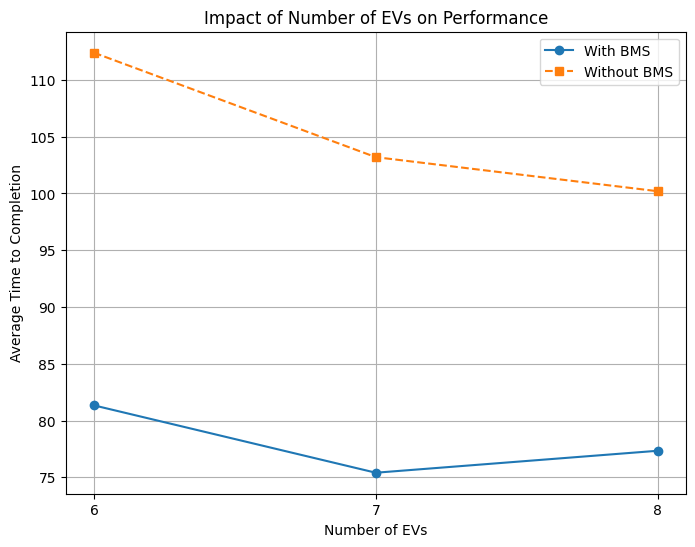

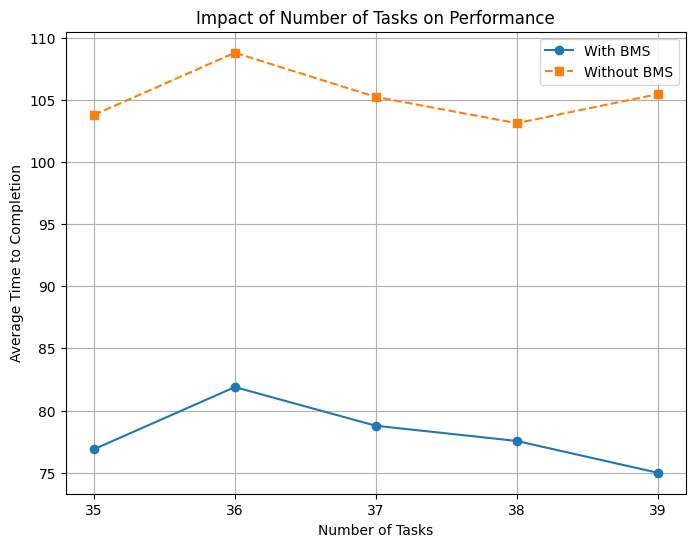

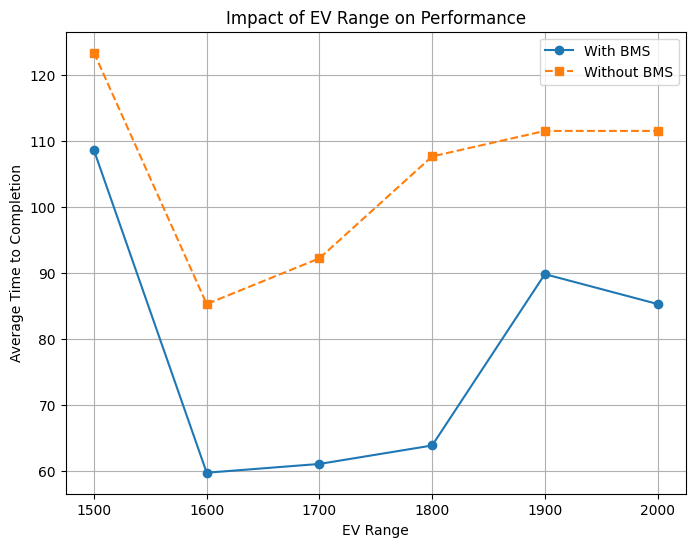

/tmp/ipykernel_21394/418406210.py:55: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["With BMS", "Without BMS"])


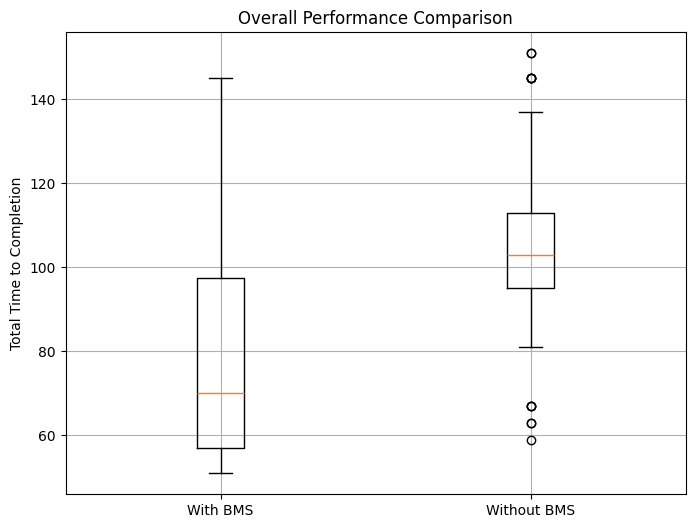

In [4]:

# Convert the time column to numeric; any non-numeric values will be set to NaN
bms_df["time"] = pd.to_numeric(bms_df["time"], errors="coerce")
non_bms_df["time"] = pd.to_numeric(non_bms_df["time"], errors="coerce")

# Function to compute average time for a given parameter while averaging over others
def get_avg_time(df, groupby_col):
    return df.groupby(groupby_col, as_index=False)["time"].mean()

# Compute averaged results for each parameter
bms_avg_evs = get_avg_time(bms_df, "num_evs")
non_bms_avg_evs = get_avg_time(non_bms_df, "num_evs")

bms_avg_tasks = get_avg_time(bms_df, "num_tasks")
non_bms_avg_tasks = get_avg_time(non_bms_df, "num_tasks")

bms_avg_range = get_avg_time(bms_df, "ev_range")
non_bms_avg_range = get_avg_time(non_bms_df, "ev_range")

# Plot 1: Number of EVs vs. Avg Time
plt.figure(figsize=(8, 6))
plt.plot(bms_avg_evs["num_evs"], bms_avg_evs["time"], marker='o', linestyle='-', label="With BMS")
plt.plot(non_bms_avg_evs["num_evs"], non_bms_avg_evs["time"], marker='s', linestyle='--', label="Without BMS")
plt.xlabel("Number of EVs")
plt.ylabel("Average Time to Completion")
plt.title("Impact of Number of EVs on Performance")
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: Number of Tasks vs. Avg Time
plt.figure(figsize=(8, 6))
plt.plot(bms_avg_tasks["num_tasks"], bms_avg_tasks["time"], marker='o', linestyle='-', label="With BMS")
plt.plot(non_bms_avg_tasks["num_tasks"], non_bms_avg_tasks["time"], marker='s', linestyle='--', label="Without BMS")
plt.xlabel("Number of Tasks")
plt.ylabel("Average Time to Completion")
plt.title("Impact of Number of Tasks on Performance")
plt.legend()
plt.grid(True)
plt.show()

# Plot 3: EV Range vs. Avg Time
plt.figure(figsize=(8, 6))
plt.plot(bms_avg_range["ev_range"], bms_avg_range["time"], marker='o', linestyle='-', label="With BMS")
plt.plot(non_bms_avg_range["ev_range"], non_bms_avg_range["time"], marker='s', linestyle='--', label="Without BMS")
plt.xlabel("EV Range")
plt.ylabel("Average Time to Completion")
plt.title("Impact of EV Range on Performance")
plt.legend()
plt.grid(True)
plt.show()

# Plot 4: Overall Performance Comparison (Boxplot)
plt.figure(figsize=(8, 6))
data = [bms_df["time"].dropna(), non_bms_df["time"].dropna()]
plt.boxplot(data, labels=["With BMS", "Without BMS"])
plt.ylabel("Total Time to Completion")
plt.title("Overall Performance Comparison")
plt.grid(True)
plt.show()


# Debugging

## EVS

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

In [21]:
df = pd.read_csv("runs/debugging_evs/debugging_evs_40_3000.csv")
# df = pd.read_csv("runs/debugging_evs/debugging_evs_100_3000.csv")
# df_1 = pd.read_csv("runs/debugging_evs/debugging_evs_bms_100_3000.csv")
df.head()

,num_evs,num_tasks,ev_range,timesteps,num_tasks_finished
0,4,40,3000,177,38
1,5,40,3000,161,38
2,6,40,3000,155,38
3,7,40,3000,119,38
4,8,40,3000,165,38


In [23]:
df = df[:10]
# df_1 = df_1[15:25]

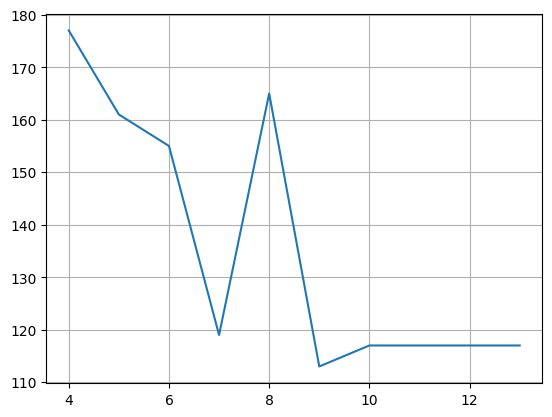

In [24]:
plt.plot(df["num_evs"], df["timesteps"])
# plt.plot(df_1["num_evs"], df_1["timesteps"])
plt.grid(True)
plt.show()

In [2]:
import ast

clusters_1, clusters_2 = [],[]
with open("runs/debugging_evs/ev_7.txt", 'r') as f1, open("runs/debugging_evs/ev_8.txt", 'r') as f2:
    l1 = f1.readlines()
    l2 = f2.readlines()
    for i in l1:
        i = i.strip()
        if len(i)>8 and i[:8] == 'Clusters':
            # Extracting the part containing the list
            start_index = i.find("Clusters") + len("Clusters")
            cluster_string = i[start_index:].strip()
            clusters_1.append(ast.literal_eval(cluster_string))
    for i in l2:
        i = i.strip()
        if len(i)>8 and i[:8] == 'Clusters':
            # Extracting the part containing the list
            start_index = i.find("Clusters") + len("Clusters")
            cluster_string = i[start_index:].strip()
            clusters_2.append(ast.literal_eval(cluster_string))
    
for i in range(1000):
    print("Iteration:",i)
    print(clusters_1[i])
    print(clusters_2[i])
    if sum(len(sublist) for sublist in clusters_1[i]) < sum(len(sublist) for sublist in clusters_2[i]):
        break

Iteration: 0
[[(35, 5), (34, 9), (34, 2)], [(7, 24), (1, 22), (5, 27)], [(24, 9), (23, 9), (27, 16), (21, 17), (25, 13), (29, 8)], [(12, 7), (13, 6), (3, 4), (11, 1), (6, 4), (12, 6), (11, 3), (13, 8)], [(11, 33), (18, 32), (11, 30), (15, 27), (17, 32)], [(6, 14), (15, 13), (2, 13), (4, 16), (7, 16), (3, 16), (11, 15)], [(25, 20), (19, 20), (32, 18), (27, 22), (31, 22), (33, 21), (27, 26), (30, 31)]]
[[(35, 5), (34, 9), (34, 2)], [(11, 33), (18, 32), (11, 30), (15, 27), (17, 32)], [(3, 4), (11, 1), (6, 4), (11, 3)], [(25, 20), (19, 20), (27, 16), (32, 18), (27, 22), (31, 22), (33, 21), (27, 26), (21, 17), (30, 31)], [(6, 14), (2, 13), (4, 16), (7, 16), (3, 16), (11, 15)], [(24, 9), (23, 9), (25, 13), (29, 8)], [(12, 7), (13, 6), (15, 13), (12, 6), (13, 8)], [(7, 24), (1, 22), (5, 27)]]
Iteration: 1
[[(35, 5), (34, 9), (34, 2)], [(7, 24), (1, 22), (5, 27)], [(24, 9), (23, 9), (27, 16), (21, 17), (25, 13), (29, 8)], [(12, 7), (13, 6), (3, 4), (11, 1), (6, 4), (12, 6), (11, 3), (13, 8)], 

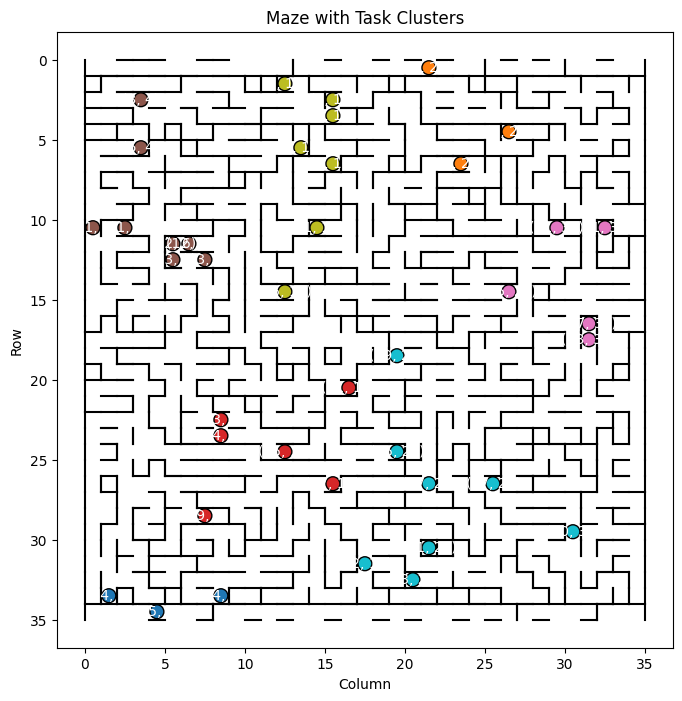

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import ast

def draw_maze_and_tasks(maze_csv, num_tasks, num_patrols):
    # Read the CSV file
    df = pd.read_csv(maze_csv)
    
    # Parse the cell string into a tuple and extract row, col
    df['  cell  '] = df['  cell  '].apply(lambda x: ast.literal_eval(x))
    df['row'] = df['  cell  '].apply(lambda t: t[0])
    df['col'] = df['  cell  '].apply(lambda t: t[1])
    
    # Create a plot for the maze
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # For each cell, draw walls where flagged (assume each cell spans from (col-1, row-1) to (col, row))
    for _, cell in df.iterrows():
        r, c = cell['row'], cell['col']
        # South wall: from (c-1, r-1) to (c, r-1)
        if cell['S'] == 0:
            ax.plot([c-1, c], [r-1, r-1], color='black')
        # North wall: from (c-1, r) to (c, r)
        if cell['N'] == 0:
            ax.plot([c-1, c], [r, r], color='black')
        # West wall: from (c-1, r-1) to (c-1, r)
        if cell['W'] == 0:
            ax.plot([c-1, c-1], [r-1, r], color='black')
        # East wall: from (c, r-1) to (c, r)
        if cell['E'] == 0:
            ax.plot([c, c], [r-1, r], color='black')
    
    # Set aspect ratio so cells appear square
    ax.set_aspect('equal')
    
    # Sample a set of tasks from the maze cells and extract (row, col)
    tasks_df = df[['row', 'col']].sample(n=num_tasks, random_state=47)
    task_list = [ (int(t[0]), int(t[1])) for t in tasks_df.values.tolist() ]
    
    # Cluster the tasks with KMeans
    kmeans = KMeans(n_clusters=num_patrols, random_state=47).fit(task_list)
    labels = kmeans.labels_
    
    # Plot the tasks on top of the maze.
    # We'll mark the center of each cell at (col - 0.5, row - 0.5)
    xs = [t[1] - 0.5 for t in task_list]  # x comes from col
    ys = [t[0] - 0.5 for t in task_list]  # y comes from row
    
    scatter = ax.scatter(xs, ys, c=labels, cmap='tab10', s=100, edgecolors='k')
    
    # Optionally, annotate each task with its cell coordinates.
    for i, (x, y) in enumerate(zip(xs, ys)):
        ax.text(x, y, str(task_list[i]), color='white', ha='center', va='center')
    
    plt.title("Maze with Task Clusters")
    plt.xlabel("Column")
    plt.ylabel("Row")
    
    # Optionally, invert y-axis if you want (e.g. so that (1,1) appears in the top-left)
    plt.gca().invert_yaxis()
    plt.show()

# Example usage:
# Assume your maze CSV is named 'maze.csv'
draw_maze_and_tasks("data/maze.csv", num_tasks=40, num_patrols=7)


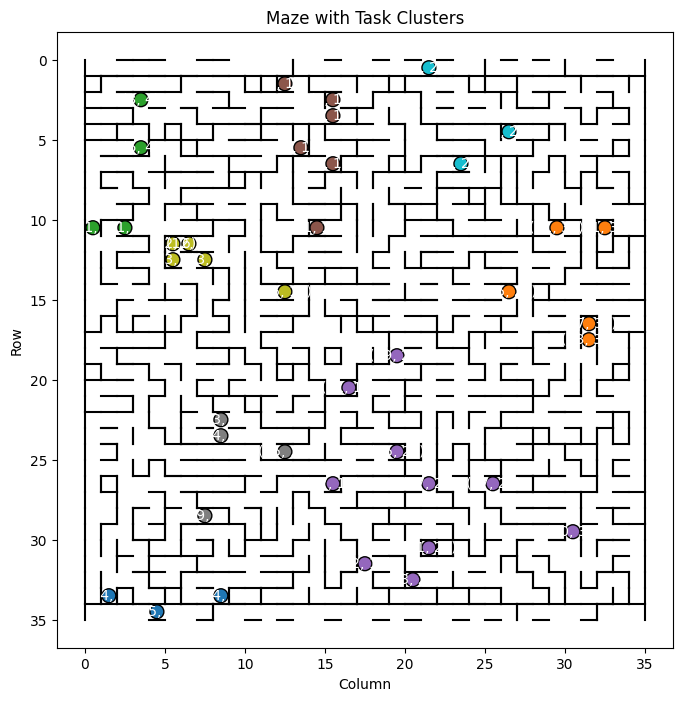

In [8]:
draw_maze_and_tasks("data/maze.csv", num_tasks=40, num_patrols=8)


## Range

In [17]:
df = pd.read_csv("runs/debugging_range/debugging_range_6_40.csv")
df_1 = pd.read_csv("runs/debugging_range/debugging_range_bms_6_40.csv")
df.head()

,num_evs,num_tasks,ev_range,timesteps,num_tasks_finished
0,6,40,10,0,0
1,6,40,20,0,0
2,6,40,30,0,0
3,6,40,40,0,0
4,6,40,50,0,0


In [33]:
df[df["num_tasks_finished"] == 38]

,num_evs,num_tasks,ev_range,timesteps,num_tasks_finished
269,6,40,2700,99,38
270,6,40,2710,99,38
271,6,40,2720,99,38
272,6,40,2730,99,38
273,6,40,2740,99,38
274,6,40,2750,99,38
275,6,40,2760,99,38
276,6,40,2770,99,38
277,6,40,2780,99,38
278,6,40,2790,99,38


In [34]:
df.tail()

,num_evs,num_tasks,ev_range,timesteps,num_tasks_finished
295,6,40,2960,99,38
296,6,40,2970,99,38
297,6,40,2980,99,38
298,6,40,2990,99,38
299,6,40,3000,99,38


In [39]:
df = df[-50:]

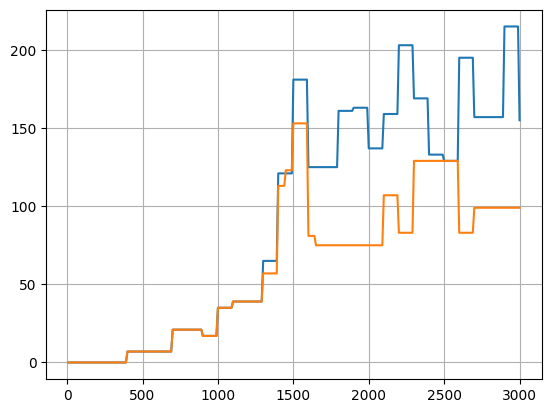

In [19]:
plt.plot(df["ev_range"], df["timesteps"])
plt.plot(df_1["ev_range"], df_1["timesteps"])
plt.grid(True)
plt.show()

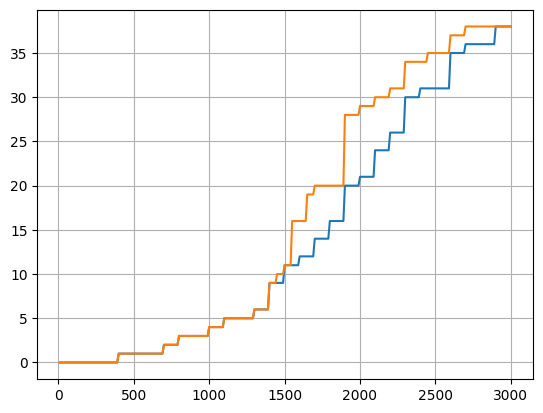

In [18]:
plt.plot(df["ev_range"], df["num_tasks_finished"])
plt.plot(df_1["ev_range"], df_1["num_tasks_finished"])
plt.grid(True)
plt.show()

## Tasks

In [47]:
df = pd.read_csv("runs/debugging_tasks/debugging_tasks_6_3000.csv")
df_1 = pd.read_csv("runs/debugging_tasks/debugging_tasks_bms_6_3000.csv")
df.head()

,num_evs,num_tasks,ev_range,timesteps,num_tasks_finished
0,6,10,3000,53,9
1,6,11,3000,53,10
2,6,12,3000,59,11
3,6,13,3000,59,12
4,6,14,3000,59,12


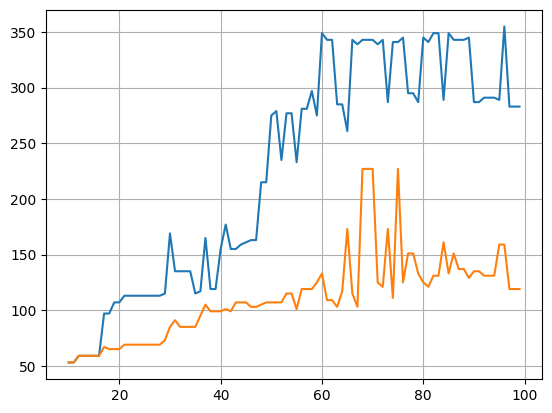

In [48]:
plt.plot(df["num_tasks"], df["timesteps"])
plt.plot(df_1["num_tasks"], df_1["timesteps"])
plt.grid(True)
plt.show()

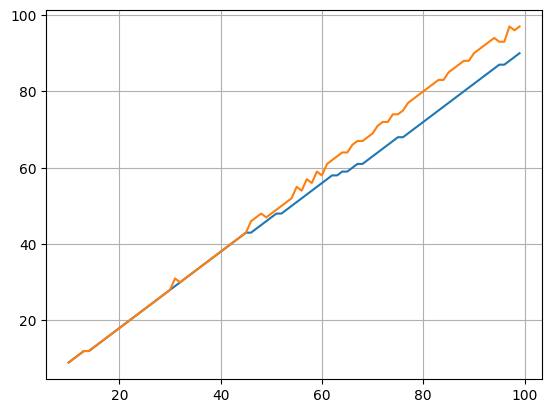

In [49]:
plt.plot(df["num_tasks"], df["num_tasks_finished"])
plt.plot(df_1["num_tasks"], df_1["num_tasks_finished"])
plt.grid(True)
plt.show()